# Hospital Readmission Fairness Audit

## Notebook 03 - Debiasing & the Fairness-Accuracy Trade-off

In [1]:
!pip -q install ucimlrepo fairlearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('diabetic_clean.csv')
except FileNotFoundError:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=296)
    df = pd.concat([ds.data.features, ds.data.targets], axis=1).replace('?', np.nan)
    df = df[df['readmitted'] != '>30'].copy()
    df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print('Data loaded:', df.shape)

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


Data loaded: (66221, 49)


### Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df[df['gender'] != 'Unknown/Invalid'].copy()
df = df.dropna(subset=['race']).reset_index(drop=True)

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
cat_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'payer_code', 'max_glu_serum', 'A1Cresult',
            'metformin', 'insulin', 'change', 'diabetesMed']

X_df = df[num_cols + cat_cols].copy()
X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
for col in cat_cols:
    X_df[col] = X_df[col].fillna('None').astype(str)

X = pd.get_dummies(X_df, columns=cat_cols)
y = df['readmit_30'].values

idx = np.arange(len(df))
Xtr, Xte, ytr, yte, itr, ite = train_test_split(
    X, y, idx, test_size=0.25, random_state=42, stratify=df['race'])

race_tr = df.iloc[itr]['race'].values
race_te = df.iloc[ite]['race'].values

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)
print('Train:', Xtr_s.shape, '  Test:', Xte_s.shape)

Train: (48363, 113)   Test: (16122, 113)


### Baseline and a shared scoring helper

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from fairlearn.metrics import (MetricFrame, false_negative_rate,
                               equalized_odds_difference, demographic_parity_difference)

def report(name, pred):
    acc = accuracy_score(yte, pred)
    eod = equalized_odds_difference(yte, pred, sensitive_features=race_te)
    dpd = demographic_parity_difference(yte, pred, sensitive_features=race_te)
    fnr = MetricFrame(metrics=false_negative_rate, y_true=yte, y_pred=pred,
                      sensitive_features=race_te)
    print('%-26s acc=%.3f  EO-diff=%.3f  DP-diff=%.3f  FNR-gap=%.3f' % (
        name, acc, eod, dpd, fnr.difference()))
    return {'method': name, 'accuracy': acc, 'EO_diff': eod,
            'DP_diff': dpd, 'FNR_gap': fnr.difference()}

base = LogisticRegression(max_iter=2000, class_weight='balanced',random_state=55)
base.fit(Xtr_s, ytr)
base_pred = base.predict(Xte_s)
results = [report('Baseline LogReg', base_pred)]

Baseline LogReg            acc=0.704  EO-diff=0.298  DP-diff=0.166  FNR-gap=0.298


### Pre-processing - reweighting

In [5]:
groups = np.unique(race_tr)
w = np.ones(len(ytr))
for g in groups:
    for lab in [0, 1]:
        mask = (race_tr == g) & (ytr == lab)
        if mask.sum() > 0:
            w[mask] = len(ytr) / (len(groups) * 2 * mask.sum())

rw = LogisticRegression(max_iter=2000, class_weight='balanced',random_state=55)
rw.fit(Xtr_s, ytr, sample_weight=w)
rw_pred = rw.predict(Xte_s)
results.append(report('Pre-proc: Reweighting', rw_pred))

Pre-proc: Reweighting      acc=0.673  EO-diff=0.109  DP-diff=0.107  FNR-gap=0.085


### In-processing - fairness-constrained training

In [6]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

eg = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced',random_state=55),
    constraints=EqualizedOdds(), max_iter=25)
eg.fit(Xtr_s, ytr, sensitive_features=race_tr)
eg_pred = eg.predict(Xte_s)
results.append(report('In-proc: ExpGradient', eg_pred))

In-proc: ExpGradient       acc=0.709  EO-diff=0.168  DP-diff=0.056  FNR-gap=0.168


### Post-processing - threshold adjustment

In [7]:
from fairlearn.postprocessing import ThresholdOptimizer

to = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=2000, class_weight='balanced',random_state=55),
    constraints='equalized_odds', objective='balanced_accuracy_score',
    predict_method='predict_proba', prefit=False)
to.fit(Xtr_s, ytr, sensitive_features=race_tr)
to_pred = to.predict(Xte_s, sensitive_features=race_te)
results.append(report('Post-proc: ThresholdOpt', to_pred))

Post-proc: ThresholdOpt    acc=0.644  EO-diff=0.272  DP-diff=0.027  FNR-gap=0.272


## Before / After and the Fairness-Accuracy Trade-off

### Did debiasing improve fairness, and at what cost?

In [8]:
res_df = pd.DataFrame(results)
print(res_df.round(3))
print()
for name, pred in [('Baseline', base_pred), ('Reweighting', rw_pred), ('ThresholdOptimizer', to_pred)]:
    mf = MetricFrame(metrics=false_negative_rate, y_true=yte, y_pred=pred,
                     sensitive_features=race_te)
    print(name, '- FNR by race:')
    print(mf.by_group.round(3))
    print()

                    method  accuracy  EO_diff  DP_diff  FNR_gap
0          Baseline LogReg     0.704    0.298    0.166    0.298
1    Pre-proc: Reweighting     0.673    0.109    0.107    0.085
2     In-proc: ExpGradient     0.709    0.168    0.056    0.168
3  Post-proc: ThresholdOpt     0.644    0.272    0.027    0.272

Baseline - FNR by race:
sensitive_feature_0
AfricanAmerican    0.386
Asian              0.684
Caucasian          0.403
Hispanic           0.621
Other              0.643
Name: false_negative_rate, dtype: float64

Reweighting - FNR by race:
sensitive_feature_0
AfricanAmerican    0.381
Asian              0.421
Caucasian          0.391
Hispanic           0.466
Other              0.381
Name: false_negative_rate, dtype: float64

ThresholdOptimizer - FNR by race:
sensitive_feature_0
AfricanAmerican    0.296
Asian              0.211
Caucasian          0.331
Hispanic           0.483
Other              0.333
Name: false_negative_rate, dtype: float64



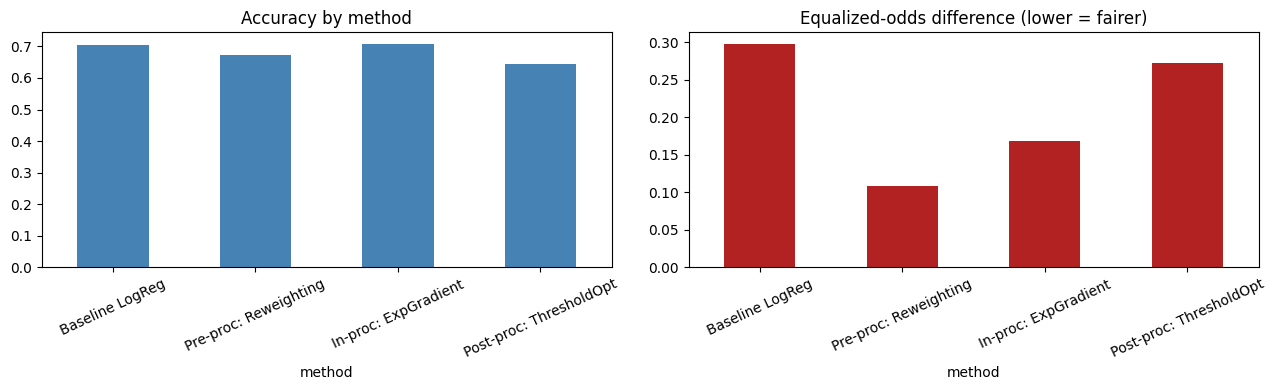

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
res_df.plot(x='method', y='accuracy', kind='bar', ax=ax[0], legend=False,
            color='steelblue', title='Accuracy by method')
res_df.plot(x='method', y='EO_diff', kind='bar', ax=ax[1], legend=False,
            color='firebrick', title='Equalized-odds difference (lower = fairer)')
for a in ax:
    a.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### The Pareto frontier

    eps  accuracy  EO_diff
0  0.01     0.709    0.190
1  0.02     0.731    0.132
2  0.05     0.719    0.187
3  0.10     0.720    0.179
4  0.20     0.730    0.263


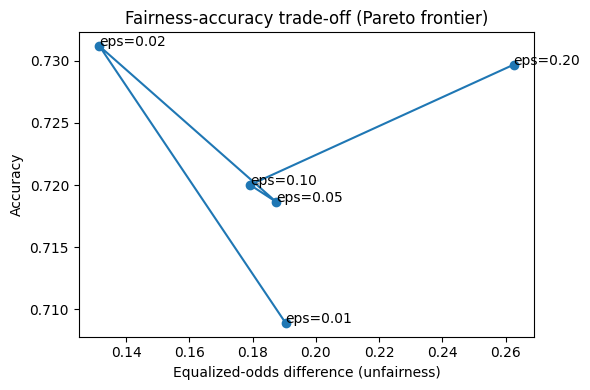

In [10]:
from sklearn.metrics import accuracy_score

pareto = []
for eps in [0.01, 0.02, 0.05, 0.1, 0.2]:
    mdl = ExponentiatedGradient(
        estimator=LogisticRegression(max_iter=800, class_weight='balanced',random_state=55),
        constraints=EqualizedOdds(difference_bound=eps), max_iter=15)
    mdl.fit(Xtr_s, ytr, sensitive_features=race_tr)
    p = mdl.predict(Xte_s)
    pareto.append({'eps': eps, 'accuracy': accuracy_score(yte, p),
                   'EO_diff': equalized_odds_difference(yte, p, sensitive_features=race_te)})
pareto = pd.DataFrame(pareto)
print(pareto.round(3))

plt.figure(figsize=(6, 4))
plt.plot(pareto['EO_diff'], pareto['accuracy'], 'o-')
for _, r in pareto.iterrows():
    plt.annotate('eps=%.2f' % r['eps'], (r['EO_diff'], r['accuracy']))
plt.xlabel('Equalized-odds difference (unfairness)')
plt.ylabel('Accuracy')
plt.title('Fairness-accuracy trade-off (Pareto frontier)')
plt.tight_layout()
plt.show()

### The impossibility result

In [11]:
base_rates = df.iloc[ite].groupby('race')['readmit_30'].mean() * 100
print('30-day readmission BASE RATE by race (test set), in %:')
print(base_rates.round(1))

30-day readmission BASE RATE by race (test set), in %:
race
AfricanAmerican    18.0
Asian              15.8
Caucasian          17.9
Hispanic           16.6
Other              15.8
Name: readmit_30, dtype: float64


In [13]:
from fairlearn.reductions import DemographicParity

dp_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=800, class_weight='balanced',random_state=55),
    constraints=DemographicParity(), max_iter=100)
dp_model.fit(Xtr_s, ytr, sensitive_features=race_tr)
dp_pred = dp_model.predict(Xte_s)

print('Model optimised for DEMOGRAPHIC PARITY:')
print('  DP-diff = %.3f  (small -> demographic parity achieved)'
      % demographic_parity_difference(yte, dp_pred, sensitive_features=race_te))
print('  EO-diff = %.3f  (remains large -> equalized odds violated)'
      % equalized_odds_difference(yte, dp_pred, sensitive_features=race_te))
print()
print('Model optimised for EQUALIZED ODDS:')
print('  DP-diff = %.3f' % demographic_parity_difference(yte, eg_pred, sensitive_features=race_te))
print('  EO-diff = %.3f' % equalized_odds_difference(yte, eg_pred, sensitive_features=race_te))
print()
print('Because base rates differ across racial groups, no single model drives')
print('both DP-diff and EO-diff to zero at once - Chouldechova (2017).')

Model optimised for DEMOGRAPHIC PARITY:
  DP-diff = 0.076  (small -> demographic parity achieved)
  EO-diff = 0.176  (remains large -> equalized odds violated)

Model optimised for EQUALIZED ODDS:
  DP-diff = 0.056
  EO-diff = 0.168

Because base rates differ across racial groups, no single model drives
both DP-diff and EO-diff to zero at once - Chouldechova (2017).
